In [1557]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..')) 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import LabelEncoder

### Загружаем реальные данные

In [1558]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
df = pd.read_csv(url, header=None, na_values='?')

# Дадим колонкам имена
df.columns = ['age','workclass','fnlwgt','education','education-num',
              'marital-status','occupation','relationship','race','sex',
              'capital-gain','capital-loss','hours-per-week','native-country','income']

# Удалим строки с пропусками (CTGAN не любит NaN)
df = df.dropna().reset_index(drop=True)

# Категориальные – по именам (соответствуют твоим индексам 0,3,4,5,6,8,9,11,12,15) [web:20]
discrete_columns = ['workclass','education','marital-status','occupation',
                    'relationship','race','sex','native-country','income']

### Выведем небольшую часть датсетов и их размерности

#### Реальные данные 

In [1559]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [1560]:
df.shape

(32561, 15)

#### Данные от KAN-CTGAN-DP

In [1561]:
base_dir = os.path.abspath('../..')
file_path = os.path.join(base_dir, 'synthetic_output_kan_ctgan_dp.csv')

In [1562]:
synthetic_data_kan_ctgan_dp = pd.read_csv(file_path)

In [1563]:
synthetic_data_kan_ctgan_dp.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,14,?,142403,HS-grad,9,Never-married,Machine-op-inspct,Not-in-family,White,Male,18,-2,40,United-States,<=50K
1,48,Local-gov,134180,HS-grad,9,Never-married,Protective-serv,Own-child,Black,Male,3206,-3,40,United-States,<=50K
2,61,?,127687,Some-college,10,Widowed,Exec-managerial,Unmarried,White,Male,4425,-2,40,United-States,<=50K
3,49,Local-gov,147654,HS-grad,9,Never-married,Sales,Not-in-family,Black,Male,42,-3,40,United-States,<=50K
4,44,Federal-gov,1048,Some-college,10,Never-married,?,Not-in-family,Black,Male,2314,-5,27,United-States,<=50K


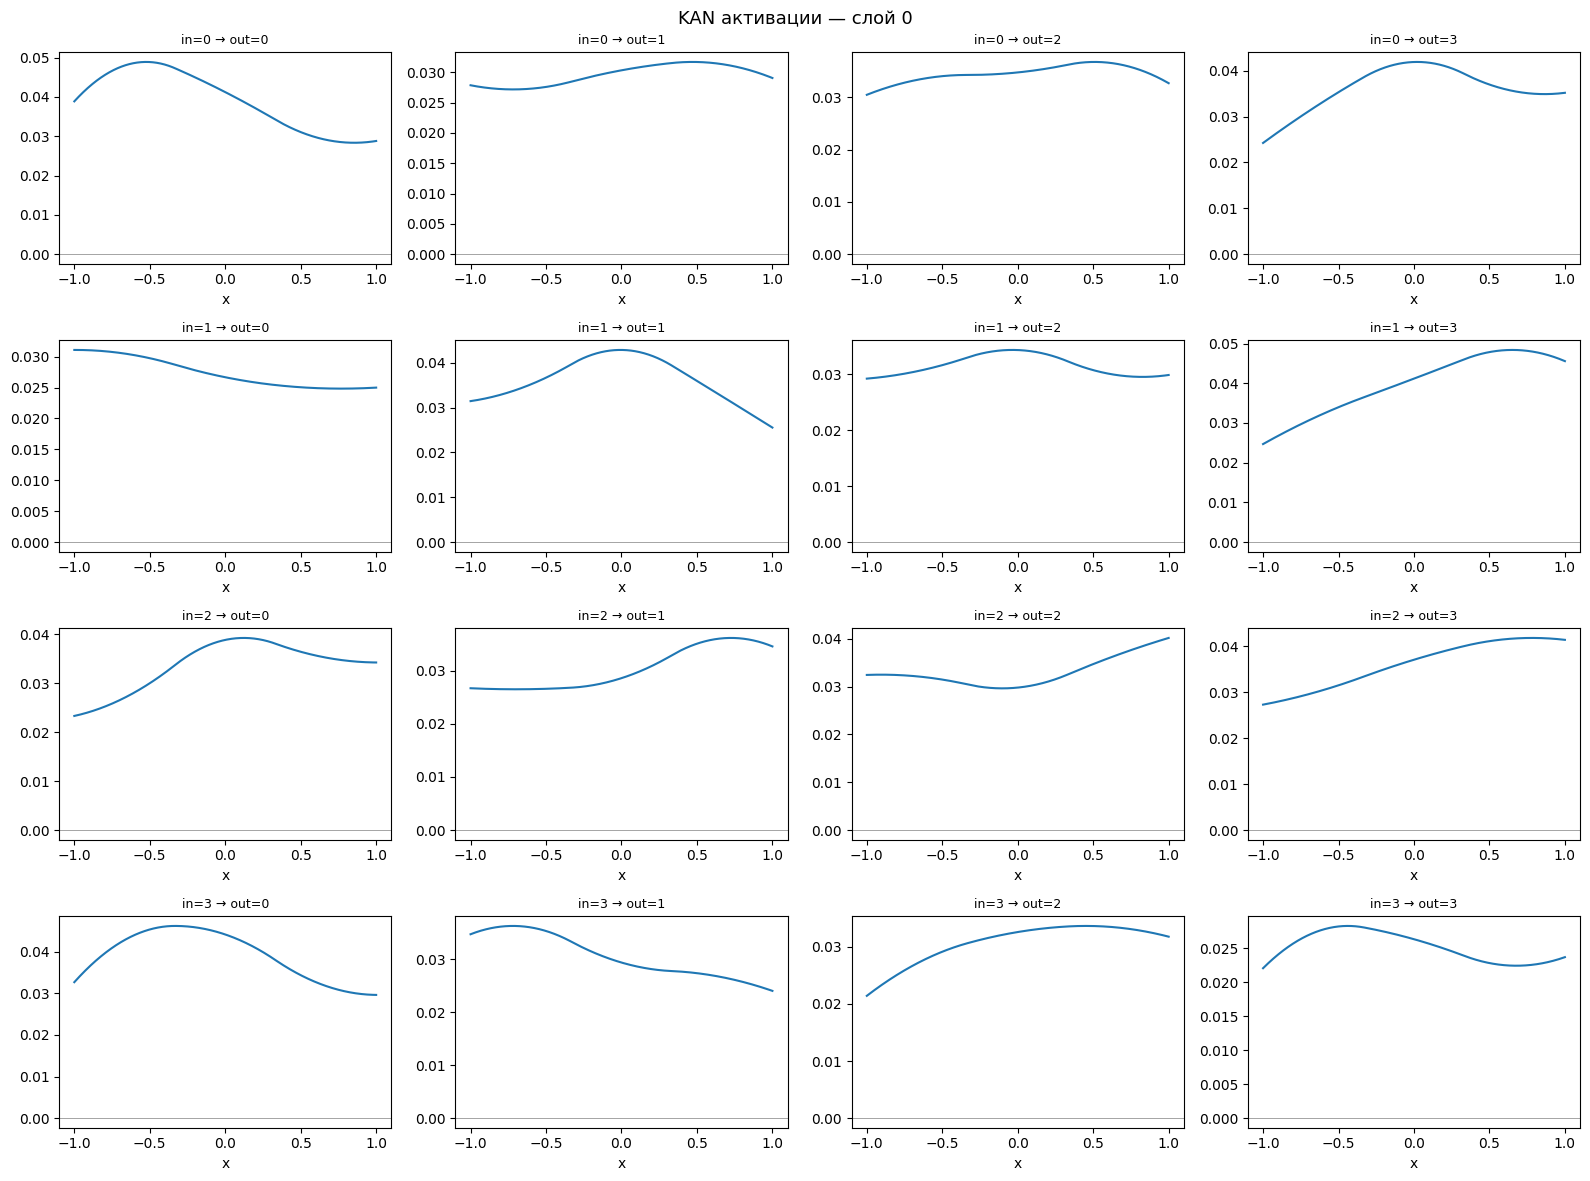

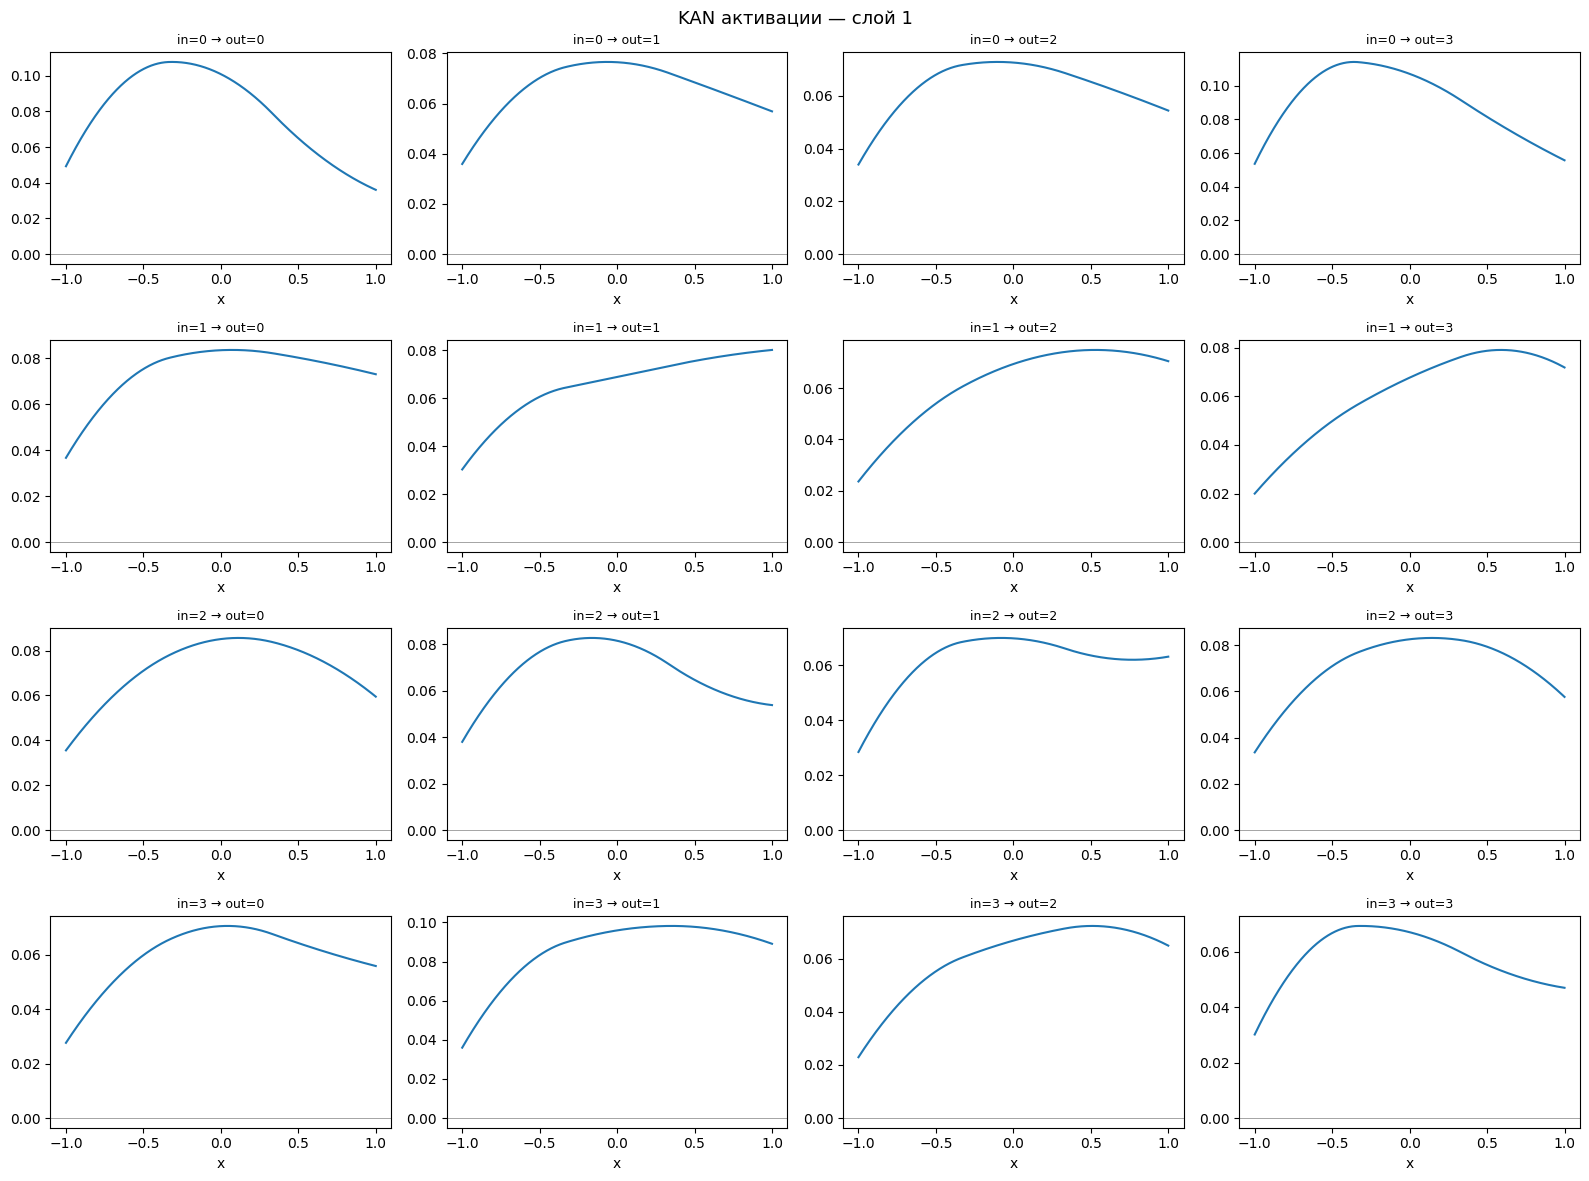

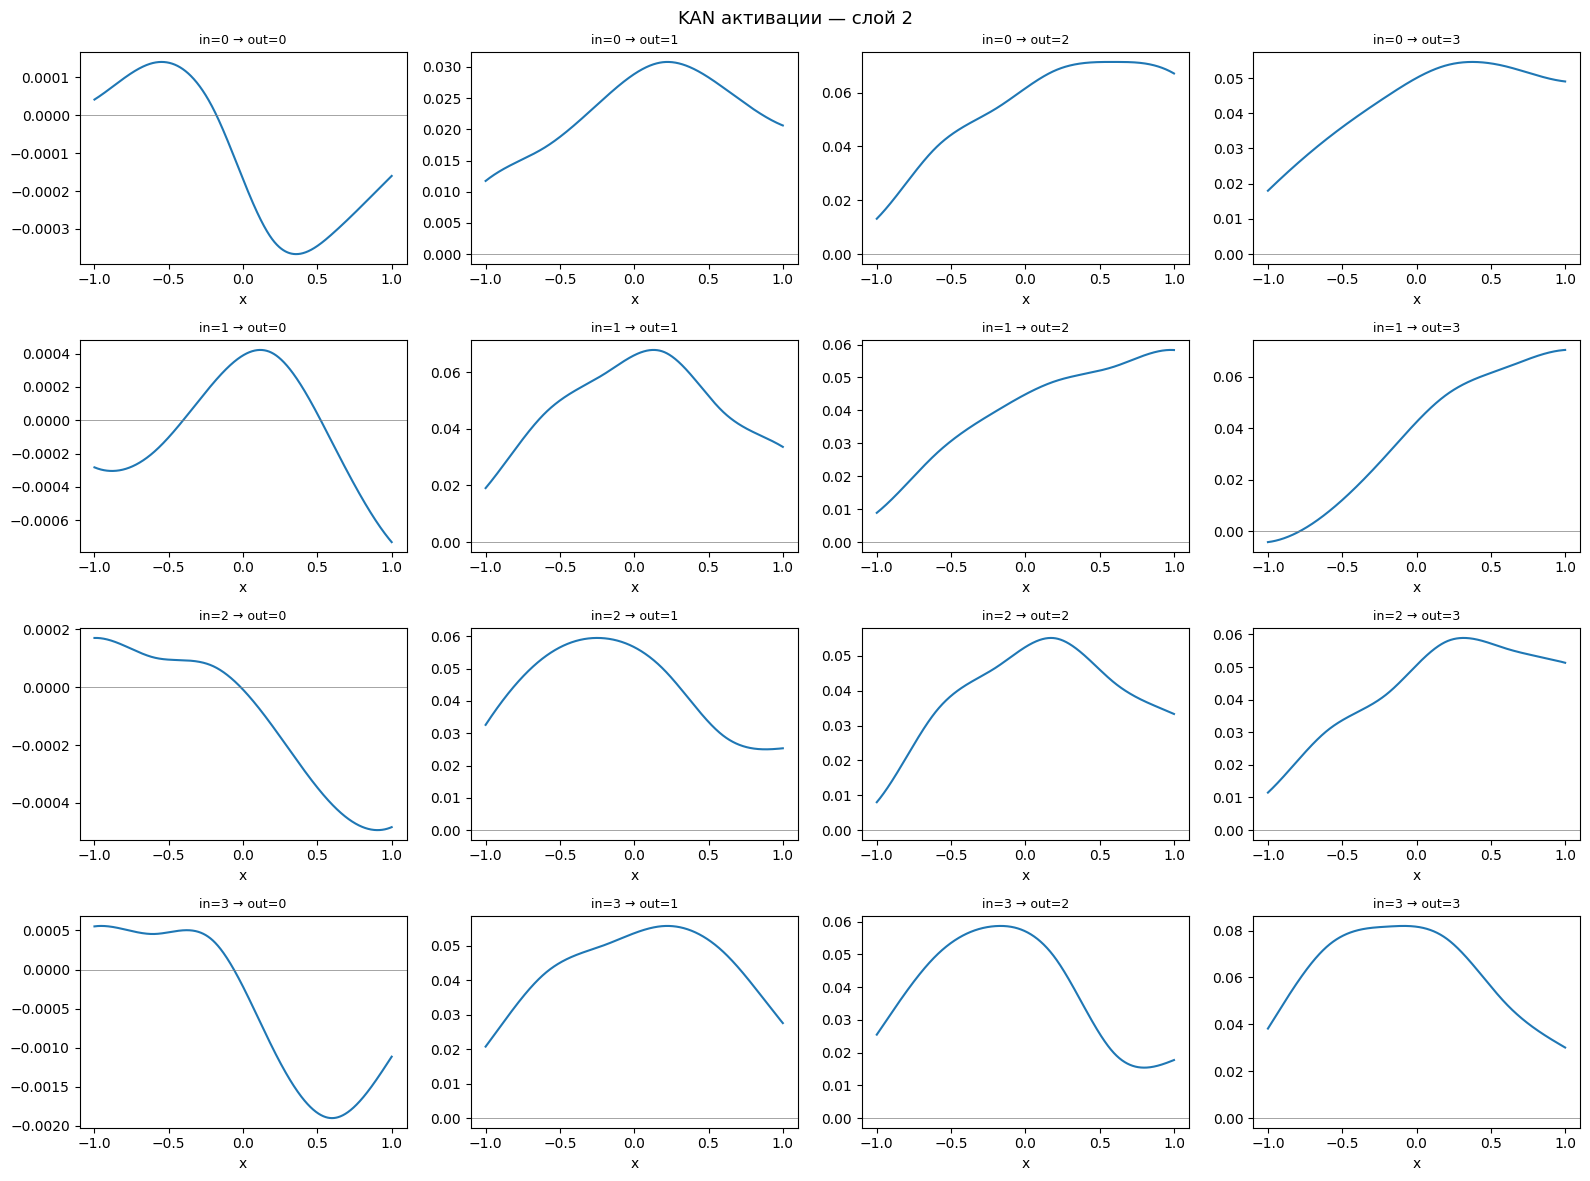

In [1564]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_kan_activations(model, n_inputs=1000, layer_idx=0, max_plots=16):
    """
    Визуализирует функции активации KANLinear слоя генератора.
    layer_idx: 0 или 1 — KAN_Residual, 2 — финальный KANLinear
    """
    # Получаем нужный KANLinear
    seq = model._generator.seq
    if layer_idx < 2:
        kan_layer = seq[layer_idx].fc  # KAN_Residual.fc
    else:
        kan_layer = seq[2]  # финальный KANLinear
    
    in_features = kan_layer.in_features
    out_features = kan_layer.out_features
    
    # Генерируем входные данные
    x = torch.linspace(-1, 1, n_inputs).unsqueeze(1).repeat(1, in_features).to(model._device)
    
    # Считаем сплайны
    with torch.no_grad():
        splines = kan_layer.b_splines(x)  # (n, in, grid+order)
        weights = kan_layer.scaled_spline_weight  # (out, in, grid+order)
    
    # Рисуем активации для первых max_plots пар (in, out)
    n = min(max_plots, in_features * out_features)
    cols = 4
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
    axes = axes.flatten()
    
    x_np = x[:, 0].cpu().numpy()
    k = 0
    for i in range(min(in_features, 4)):
        for j in range(min(out_features, 4)):
            if k >= n:
                break
            activation = (splines[:, i, :].cpu() @ weights[j, i, :].cpu()).numpy()
            axes[k].plot(x_np, activation)
            axes[k].set_title(f'in={i} → out={j}', fontsize=9)
            axes[k].axhline(0, color='gray', linewidth=0.5)
            axes[k].set_xlabel('x')
            k += 1
    
    # Скрываем пустые графики
    for ax in axes[k:]:
        ax.axis('off')
    
    plt.suptitle(f'KAN активации — слой {layer_idx}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'kan_activations_layer{layer_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Загружаем модель и вызываем

base_dir = os.path.abspath('../..')
file_path = os.path.join(base_dir, 'synthesizer_kan_ctgan_dp.pkl')

import pickle
with open(file_path, 'rb') as f:
    model = pickle.load(f)

plot_kan_activations(model, layer_idx=0)
plot_kan_activations(model, layer_idx=1)
plot_kan_activations(model, layer_idx=2)

In [1565]:
synthetic_data_kan_ctgan_dp.shape

(32561, 15)

#### Данные от CTGAN

In [1566]:
base_dir = os.path.abspath('../..')
file_path = os.path.join(base_dir, 'synthetic_output_ctgan.csv')

In [1567]:
synthetic_data_ctgan = pd.read_csv(file_path, na_values='?')

In [1568]:
synthetic_data_ctgan.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,48,Self-emp-inc,280717,HS-grad,9,Divorced,Handlers-cleaners,Unmarried,White,Male,45,-2,40,United-States,<=50K
1,41,Local-gov,179895,Masters,14,Widowed,Prof-specialty,Not-in-family,White,Male,3,1,48,United-States,<=50K
2,52,Private,15570,Assoc-voc,11,Married-civ-spouse,Other-service,Wife,White,Female,-28,-6,40,United-States,<=50K
3,46,Private,11992,7th-8th,1,Widowed,Priv-house-serv,Not-in-family,White,Female,-18,2,31,United-States,<=50K
4,16,Private,197299,Some-college,10,Never-married,Adm-clerical,Own-child,White,Male,13,-1,22,United-States,<=50K


In [1569]:
synthetic_data_ctgan.shape

(32561, 15)

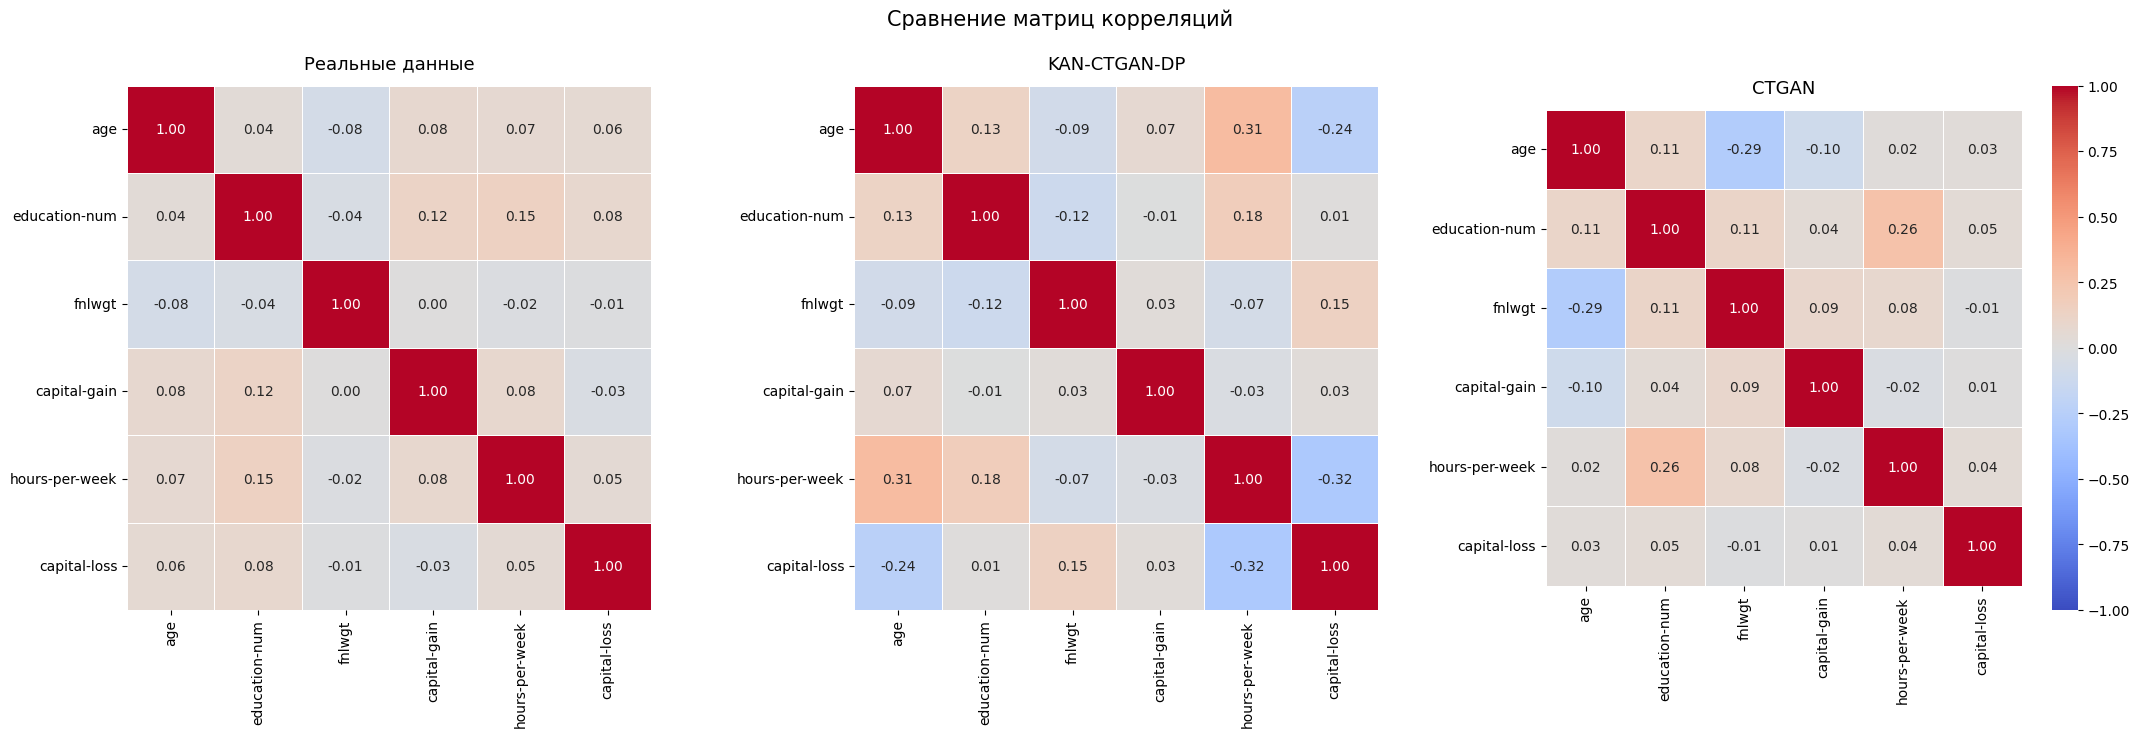

In [1570]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Считаем корреляции для каждого датасета
corr_real = df[numeric_cols].corr()
corr_kan  = synthetic_data_kan_ctgan_dp[numeric_cols].corr()
corr_ctgan = synthetic_data_ctgan[numeric_cols].corr()

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

datasets = [
    (corr_real,  "Реальные данные"),
    (corr_kan,   "KAN-CTGAN-DP"),
    (corr_ctgan, "CTGAN"),
]

for ax, (corr, title) in zip(axes, datasets):
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        square=True,
        vmin=-1, vmax=1,          # одинаковая шкала у всех
        cbar=ax == axes[-1],      # colorbar только у последнего
        ax=ax
    )
    ax.set_title(title, fontsize=13, pad=12)

plt.suptitle("Сравнение матриц корреляций", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("correlation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [1571]:
import pickle

base_dir = os.path.abspath('../..')
file_path = os.path.join(base_dir, 'synthesizer_kan_ctgan_dp.pkl')

with open(file_path, 'rb') as f:
    model = pickle.load(f)

print(vars(model))

{'_embedding_dim': 128, '_generator_dim': (256, 256), '_discriminator_dim': (256, 256), '_grid_size_gen': 3, '_spline_order_gen': 2, 'target_epsilon': 5, 'target_delta': 3.071158748195694e-05, '_generator_lr': 0.0003, '_generator_decay': 0.001, '_discriminator_lr': 0.0005, '_discriminator_decay': 1e-05, '_batch_size': 500, '_discriminator_steps': 2, '_log_frequency': True, '_verbose': True, '_epochs': 200, 'pac': 1, '_device': device(type='cuda'), '_transformer': <ctgan.data_transformer.DataTransformer object at 0x000001545208FC70>, '_data_sampler': <ctgan.data_sampler.DataSampler object at 0x0000015480B9EBC0>, '_generator': KAN_Generator(
  (seq): Sequential(
    (0): KAN_Residual(
      (fc): KANLinear(
        (base_activation): SiLU()
      )
      (bn): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (silu): SiLU()
    )
    (1): KAN_Residual(
      (fc): KANLinear(
        (base_activation): SiLU()
      )
      (bn): LayerNorm((256,), eps=1e-05, elementwise_affine=Tr

### Выведем распределения данных

### Train/Test split для df

In [1572]:
col = 'hours-per-week'

In [1573]:
X_df = df.drop(col, axis=1)
y_df = df[col]

In [1574]:
X_df_train, X_df_test, y_df_train, y_df_test = train_test_split(X_df, y_df, test_size=0.2, random_state=42)

### Train/Test split для synthetic_data_kan_ctgan_dp

In [1575]:
X_synt_kan_ctgan = synthetic_data_kan_ctgan_dp.drop(col, axis=1)
y_synt_kan_ctgan = synthetic_data_kan_ctgan_dp[col]

In [1576]:
X_synt_kan_ctgan_train, X_synt_kan_ctgan_test, y_synt_kan_ctgan_train, y_synt_kan_ctgan_test = train_test_split(X_synt_kan_ctgan, y_synt_kan_ctgan, test_size=0.2, random_state=42)

### Train/Test split для synthetic_data_ctgan

In [1577]:
X_synt_ctgan = synthetic_data_ctgan.drop(col, axis=1)
y_synt_ctgan = synthetic_data_ctgan[col]

In [1578]:
X_synt_ctgan_train, X_synt_ctgan_test, y_synt_ctgan_train, y_synt_ctgan_test = train_test_split(X_synt_ctgan, y_synt_ctgan, test_size=0.2, random_state=42)

### Обучаем модель: На реальных данных, синтетике от кастомной модели и синтетике от CTGAN

In [1579]:
def encode_X(X):
    le = LabelEncoder()
    X_enc = X.copy()
    for col in X_enc.select_dtypes(include='object').columns:
        X_enc[col] = le.fit_transform(X_enc[col].astype(str))
    return X_enc

In [1580]:
X_train_enc_1 = encode_X(X_df_train)
X_test_enc_1 = encode_X(X_df_test)

In [1581]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [1582]:
model.fit(X_train_enc_1, y_df_train)
df_preds = model.predict(X_test_enc_1)
df_preds

array([38.18, 42.05, 45.03, ..., 51.25, 38.25, 30.7 ])

In [1583]:
X_train_enc_2 = encode_X(X_synt_kan_ctgan_train)
X_test_enc_2 = encode_X(X_synt_kan_ctgan_test)

In [1584]:
model.fit(X_train_enc_2, y_synt_kan_ctgan_train)
kan_ctgan_dp_preds = model.predict(X_test_enc_1)
kan_ctgan_dp_preds

array([27.26, 32.56, 36.32, ..., 48.04, 31.45, 31.86])

In [1585]:
X_train_enc_3 = encode_X(X_synt_ctgan_train)
X_test_enc_3 = encode_X(X_synt_ctgan_test)

In [1586]:
model.fit(X_train_enc_3, y_synt_ctgan_train)
ctgan_preds = model.predict(X_test_enc_1)
ctgan_preds

array([39.74, 29.07, 43.9 , ..., 51.68, 40.51, 31.71])

### Сравним метрики

In [1587]:
mae_real = mean_absolute_error(y_df_test, df_preds)
r2_real = r2_score(y_df_test, df_preds)

print("MAE:", mean_absolute_error(y_df_test, df_preds))
print("RMSE:", mean_squared_error(y_df_test, df_preds))
print("R2:", r2_score(y_df_test, df_preds))

MAE: 7.689065408864811
RMSE: 121.15033350008734
R2: 0.2134059602543249


In [1588]:
mae_kan = mean_absolute_error(y_df_test, kan_ctgan_dp_preds)
r2_kan = r2_score(y_df_test, kan_ctgan_dp_preds)

print("MAE:", mean_absolute_error(y_df_test, kan_ctgan_dp_preds))
print("RMSE:", mean_squared_error(y_df_test, kan_ctgan_dp_preds))
print("R2:", r2_score(y_df_test, kan_ctgan_dp_preds))

MAE: 11.28890373099954
RMSE: 206.31893927529558
R2: -0.3395691388705948


In [1589]:
mae_ctgan = mean_absolute_error(y_df_test, ctgan_preds)
r2_ctgan = r2_score(y_df_test, ctgan_preds)

print("MAE:", mean_absolute_error(y_df_test, ctgan_preds))
print("RMSE:", mean_squared_error(y_df_test, ctgan_preds))
print("R2:", r2_score(y_df_test, ctgan_preds))

MAE: 8.371192998618149
RMSE: 145.01544692154152
R2: 0.05845668828094763


In [1590]:
# Utility Score — насколько близко к реальному
utility_kan = 1 - (mae_kan - mae_real) / mae_real
utility_ctgan = 1 - (mae_ctgan - mae_real) / mae_real

print(f"Utility KAN-CTGAN-DP: {utility_kan:.3f}")
print(f"Utility CTGAN:        {utility_ctgan:.3f}")

# Относительная потеря R2
r2_loss_kan = (r2_real - r2_kan) / abs(r2_real) * 100
r2_loss_ctgan = (r2_real - r2_ctgan) / abs(r2_real) * 100

print(f"\nПотеря R2 KAN-CTGAN-DP: {r2_loss_kan:.1f}%")
print(f"Потеря R2 CTGAN:        {r2_loss_ctgan:.1f}%")

Utility KAN-CTGAN-DP: 0.532
Utility CTGAN:        0.911

Потеря R2 KAN-CTGAN-DP: 259.1%
Потеря R2 CTGAN:        72.6%


### Рассмотрим распределение данных

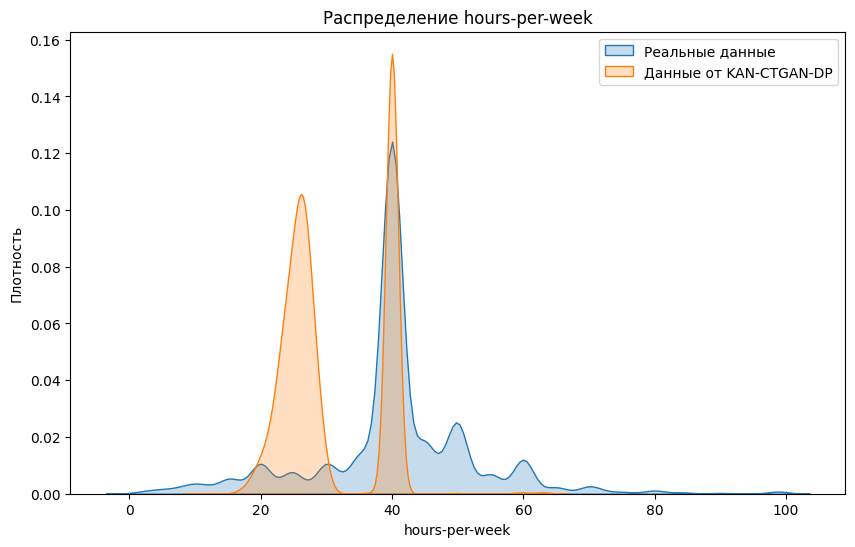

In [1591]:
plt.figure(figsize=(10,6))
sns.kdeplot(df[col], label = 'Реальные данные', fill=True)
sns.kdeplot(synthetic_data_kan_ctgan_dp[col], label = 'Данные от KAN-CTGAN-DP', fill=True)
plt.title(f'Распределение {col}')
plt.xlabel(col)
plt.ylabel('Плотность')
plt.legend()
plt.show()

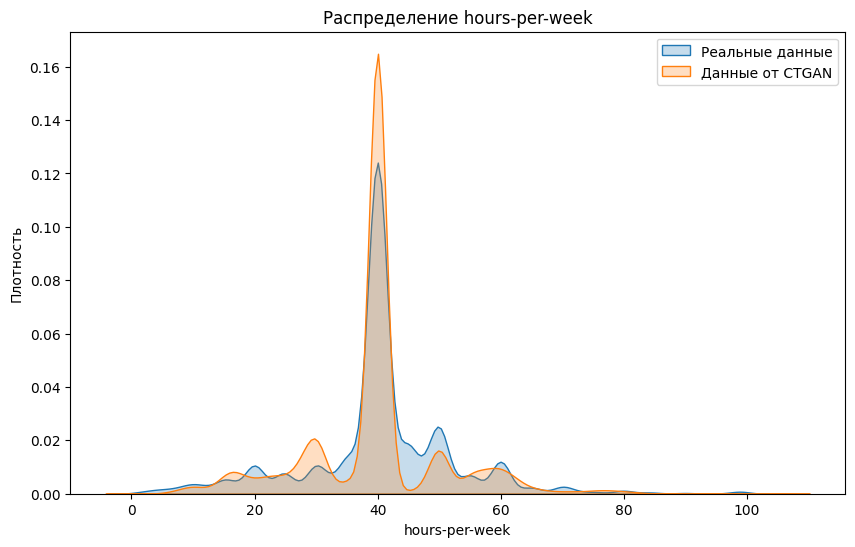

In [1592]:
plt.figure(figsize=(10,6))
sns.kdeplot(df[col], label = 'Реальные данные', fill=True)
sns.kdeplot(synthetic_data_ctgan[col], label = 'Данные от CTGAN', fill=True)
plt.title(f'Распределение {col}')
plt.xlabel(col)
plt.ylabel('Плотность')
plt.legend()
plt.show()